# AI-Based Text Summarization of Research Papers
### Transformer Encoder-Decoder Architecture (T5 / BART / PEGASUS)

**Course:** Natural Language Processing - Assignment 2 (Problem Statement 5)
**Team Number:** 163   
**Team Details:**  
AMARJIT SINGH	        2025aa05130  
MANJUNATH S	            2025aa05935  
SAURAV SINHA	        2025aa05427  
SOUMYA KANT DAS	        2025aa05372  
VIPUL PRAKASH CHAUDHARI	2025aa05991   

---

## Problem Definition
Researchers and students must read a large number of lengthy, technically dense scientific
papers to stay current. Manual analysis is slow. This project builds an **end-to-end NLP
system** that automatically produces **abstractive summaries** of research papers using
pre-trained **Transformer encoder-decoder** models, while also extracting the key
structured information (objective, methodology, dataset, findings, conclusion).

## Objectives
1. Generate concise summaries from lengthy research papers.
2. Extract important information - *research objective, methodology, dataset used, key findings, conclusion*.
3. Reduce time required for literature review.
4. Provide a quick understanding of scientific documents.

## NLP Processing Pipeline
```
Research Paper (PDF)  ->  PDF Text Extraction  ->  Text Cleaning & Preprocessing
   ->  Sentence / Subword Tokenization  ->  Transformer Encoder (T5 / BART / PEGASUS)
   ->  Self-Attention / Cross-Attention  ->  Transformer Decoder
   ->  Abstractive Summary + Structured Info  ->  Evaluation (ROUGE / BLEU / Perplexity)
```

## Dataset
**Kaggle - ArXiv Scientific Paper Dataset / PubMed Research Articles Dataset.**
Each record contains the full-text `article` and an author-written `abstract`
(used as the reference/ground-truth summary for evaluation).

> The notebook first tries to download the dataset with the **Kaggle API**. If Kaggle
> credentials are not configured on the machine, it automatically falls back to the same
> ArXiv scientific-papers corpus hosted on the Hugging Face Hub, and finally to a small
> built-in sample - so the notebook always runs and produces output.

## 1. Environment Setup & Imports

In [3]:
import sys, os, platform
import datetime, socket
import os, re, sys, math, warnings, random, textwrap, logging
warnings.filterwarnings("ignore")
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import numpy as np
import pandas as pd
import torch

import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    AutoModelForCausalLM,
)

# keep the notebook output clean (suppress info/warnings & progress bars)
transformers.logging.set_verbosity_error()
try:
    transformers.utils.logging.disable_progress_bar()
except Exception:
    pass
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

exec_timestamp = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
vm_hostname = socket.gethostname()
os_info = platform.platform()
py_version = platform.python_version()
user_name = os.getenv('USER', os.getenv('USERNAME', 'unknown'))

print('=' * 60)
print('EXECUTION ENVIRONMENT DETAILS')
print('=' * 60)
print(f'Timestamp       : {exec_timestamp}')
print(f'Hostname / VM ID: {vm_hostname}')
print(f'OS Platform     : {os_info}')
print(f'Python Version  : {py_version}')
print(f'Login User      : {user_name}')
print(f'Device          : {DEVICE}')
print('=' * 60)

EXECUTION ENVIRONMENT DETAILS
Timestamp       : 2026-08-23 21:54:02
Hostname / VM ID: 2025aa05935
OS Platform     : Linux-5.14.0-503.31.1.el9_5.x86_64-x86_64-with-glibc2.34
Python Version  : 3.9.21
Login User      : cloud
Device          : cpu


## 2. Configuration

In [2]:
# ---- Models (Transformer encoder-decoder architectures) ----
T5_MODEL      = "t5-base"                       # Text-to-Text Transfer Transformer
BART_MODEL    = "sshleifer/distilbart-cnn-12-6" # BART (distilled, fine-tuned for summarization)
PEGASUS_MODEL = "google/pegasus-arxiv"          # PEGASUS pre-tuned on ArXiv papers (~2.2 GB)

RUN_PEGASUS   = True    # set False to skip PEGASUS (avoids the ~2.2 GB download)

# ---- Perplexity language model ----
PPL_MODEL     = "gpt2"

# ---- Data / evaluation sizes (kept modest for runtime) ----
N_EVAL_SAMPLES = 6         # number of papers used for quantitative evaluation
MIN_ARTICLE_CHARS = 1500
MAX_ARTICLE_CHARS = 40000  # truncate very long papers to bound runtime
MAX_INPUT_CHUNKS = 8       # max encoder chunks per paper (map-reduce summarization)

# ---- Dataset selection ----
# The Kaggle "ArXiv" dataset (Cornell) contains only metadata + abstracts, which makes
# summarization near-trivial (input ~= reference). To genuinely demonstrate long research-
# paper summarization we default to the full-text ArXiv scientific-papers corpus (same
# ArXiv source). Set USE_KAGGLE_METADATA = True to use the exact Kaggle download instead.
USE_KAGGLE_METADATA = False
KAGGLE_DATASET = "Cornell-University/arxiv"   # ArXiv scientific paper dataset on Kaggle

# ---- Generation defaults ----
GEN_KWARGS = dict(num_beams=4, no_repeat_ngram_size=3,
                  length_penalty=2.0, early_stopping=True)

## 3. Dataset Acquisition (ArXiv Scientific Paper Dataset)

We obtain `(article, abstract)` pairs where the author-written `abstract` is the reference
(ground-truth) summary for evaluation.

The assignment specifies the **Kaggle ArXiv / PubMed** dataset. The Kaggle
*Cornell-University/arxiv* release contains paper **metadata + abstracts** (no full text),
which makes summarization almost trivial. To faithfully demonstrate **long research-paper**
summarization we default to the **full-text ArXiv scientific-papers corpus** (the same ArXiv
source, summarization-ready):

- `USE_KAGGLE_METADATA = False` -> full-text ArXiv papers (default).
- `USE_KAGGLE_METADATA = True`  -> download the exact Kaggle dataset via `kagglehub`.

If a source is unavailable the loader falls back automatically, so the notebook always runs.

In [3]:
def _from_huggingface(n):
    # ArXiv scientific-papers corpus (FULL TEXT) via the Hugging Face Hub.
    from huggingface_hub import hf_hub_download
    import pyarrow.parquet as pq
    fp = hf_hub_download("ccdv/arxiv-summarization",
                         filename="section/train-00000-of-00015.parquet",
                         repo_type="dataset")
    out = []
    for batch in pq.ParquetFile(fp).iter_batches(batch_size=64,
                                                 columns=["article", "abstract"]):
        for rec in batch.to_pylist():
            art = re.sub(r"\s+", " ", (rec.get("article") or "")).strip()
            abt = re.sub(r"\s+", " ", (rec.get("abstract") or "")).strip()
            if len(art) >= MIN_ARTICLE_CHARS and 100 < len(abt) < 3000 and len(abt) < len(art):
                out.append({"article": art, "abstract": abt})
        if len(out) >= n:
            break
    return out


def _from_kaggle(n):
    # Primary: download the ArXiv dataset via the Kaggle API (needs kaggle.json).
    import kagglehub, glob, json
    path = kagglehub.dataset_download(KAGGLE_DATASET)
    files = glob.glob(os.path.join(path, "**", "*.json"), recursive=True)
    if not files:
        raise FileNotFoundError("No JSON found in Kaggle dataset download.")
    out = []
    with open(files[0], "r", encoding="utf-8") as f:
        for line in f:
            try:
                rec = json.loads(line)
            except Exception:
                continue
            art = (rec.get("abstract") or "").strip()   # Cornell arxiv = metadata + abstract
            title = (rec.get("title") or "").strip()
            if len(art) >= 200:
                # Use title+abstract as 'article', abstract as reference summary
                out.append({"article": (title + ". " + art).strip(), "abstract": art})
            if len(out) >= n:
                break
    return out


_BUILTIN = [{
    "article": ("Transformer models have become the dominant architecture in natural language "
        "processing. In this work we study abstractive summarization of long scientific "
        "documents. We propose an encoder-decoder approach based on self-attention that reads "
        "the full paper and generates a concise abstract. We evaluate on the arXiv corpus and "
        "report ROUGE and BLEU scores, showing that pre-trained transformers substantially "
        "reduce the effort of literature review while preserving the original meaning."),
    "abstract": ("We present a transformer encoder-decoder model for abstractive summarization "
        "of scientific papers and show strong ROUGE/BLEU results on the arXiv corpus.")
}]


def load_dataset_samples(n=N_EVAL_SAMPLES + 2):
    if USE_KAGGLE_METADATA:
        order = [("Kaggle (Cornell arXiv metadata)", _from_kaggle),
                 ("HuggingFace (full-text arXiv)", _from_huggingface)]
    else:
        order = [("HuggingFace (full-text arXiv)", _from_huggingface),
                 ("Kaggle (Cornell arXiv metadata)", _from_kaggle)]
    for name, fn in order:
        try:
            data = fn(n)
            if data:
                print(f"Loaded {len(data)} papers from: {name}")
                return data, name
        except Exception as e:
            print(f"[{name}] unavailable -> {type(e).__name__}: {str(e)[:140]}")
    print("Using built-in sample.")
    return _BUILTIN, "builtin"


DATA, DATA_SOURCE = load_dataset_samples()
print("\nExample article (first 400 chars):\n", DATA[0]["article"][:400], "...")
print("\nReference abstract (first 300 chars):\n", DATA[0]["abstract"][:300], "...")

Loaded 62 papers from: HuggingFace (full-text arXiv)

Example article (first 400 chars):
 additive models @xcite provide an important family of models for semiparametric regression or classification . some reasons for the success of additive models are their increased flexibility when compared to linear or generalized linear models and their increased interpretability when compared to fully nonparametric models . it is well - known that good estimators in additive models are in general ...

Reference abstract (first 300 chars):
 additive models play an important role in semiparametric statistics . this paper gives learning rates for regularized kernel based methods for additive models . these learning rates compare favourably in particular in high dimensions to recent results on optimal learning rates for purely nonparametr ...


## 4. PDF Text Extraction

Research papers arrive as PDFs. We use **PyMuPDF** to extract raw text. To make the step
reproducible we first render one dataset article into a demo PDF, then extract text back
from it - mirroring the real *Research Paper (PDF) -> PDF Text Extraction* stage.

In [4]:
import pymupdf as fitz  # PyMuPDF (import name updated in recent versions)

def make_demo_pdf(text, path, words_per_page=340):
    doc = fitz.open()
    rect = fitz.Rect(45, 55, 550, 790)
    words = text.split()
    for i in range(0, len(words), words_per_page):
        page = doc.new_page(width=595, height=842)
        page.insert_textbox(rect, " ".join(words[i:i + words_per_page]),
                            fontsize=9, fontname="helv", align=0)
    if len(doc) == 0:
        doc.new_page()
    doc.save(path); doc.close()
    return path


def extract_text_from_pdf(path):
    doc = fitz.open(path)
    text = "\n".join(page.get_text() for page in doc)
    doc.close()
    return text


DEMO_PDF = "sample_paper.pdf"
make_demo_pdf(DATA[0]["article"], DEMO_PDF)
raw_pdf_text = extract_text_from_pdf(DEMO_PDF)

print(f"Created '{DEMO_PDF}' and extracted {len(raw_pdf_text)} characters.\n")
print("Extracted text (first 500 chars):\n")
print(raw_pdf_text[:500], "...")

Created 'sample_paper.pdf' and extracted 26038 characters.

Extracted text (first 500 chars):

additive models @xcite provide an important family of models for semiparametric regression or classification . some reasons
for the success of additive models are their increased flexibility when compared to linear or generalized linear models and their
increased interpretability when compared to fully nonparametric models . it is well - known that good estimators in additive
models are in general less prone to the curse of high dimensionality than good estimators in fully nonparametric models . ...


## 5. Text Cleaning, Preprocessing & Sentence Tokenization

We normalise whitespace, fix hyphenated line-breaks, strip control characters and URLs,
then split the document into sentences with **NLTK**.

In [5]:
import nltk
for pkg in ["punkt", "punkt_tab"]:
    try:
        nltk.data.find(f"tokenizers/{pkg}")
    except LookupError:
        try:
            nltk.download(pkg, quiet=True)
        except Exception:
            pass
from nltk.tokenize import sent_tokenize


def clean_text(text):
    text = text.replace("\r", " ")
    text = re.sub(r"(\w)-\n(\w)", r"\1\2", text)      # de-hyphenate line breaks
    text = re.sub(r"http\S+|www\.\S+", " ", text)      # drop URLs
    text = re.sub(r"[^\x09\x0A\x0D\x20-\x7E]", " ", text)  # non-printable -> space
    text = re.sub(r"\s+", " ", text)                   # collapse whitespace
    return text.strip()


def sentence_tokenize(text):
    try:
        return [s.strip() for s in sent_tokenize(text) if s.strip()]
    except Exception:
        return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]


clean_doc = clean_text(raw_pdf_text)
sentences = sentence_tokenize(clean_doc)

print(f"Characters after cleaning : {len(clean_doc)}")
print(f"Sentences detected        : {len(sentences)}\n")
print("First 3 sentences:")
for s in sentences[:3]:
    print(" -", textwrap.shorten(s, width=140))

Characters after cleaning : 26024
Sentences detected        : 176

First 3 sentences:
 - additive models @xcite provide an important family of models for semiparametric regression or classification .
 - some reasons for the success of additive models are their increased flexibility when compared to linear or generalized linear models [...]
 - it is well - known that good estimators in additive models are in general less prone to the curse of high dimensionality than good [...]


## 6. Subword Tokenization (Transformer input representation)

Transformers operate on **subword tokens**. Below we show how the model tokenizer converts
text into token ids that feed the encoder. A leading `_` marks the start of a new word
(byte-level BPE space marker).

In [6]:
_demo_tok = AutoTokenizer.from_pretrained(BART_MODEL)
sample_sentence = sentences[0] if sentences else clean_doc[:200]

enc = _demo_tok(sample_sentence, return_tensors="pt")
tokens = _demo_tok.convert_ids_to_tokens(enc["input_ids"][0])[:25]
# byte-level BPE marks a leading space with a special glyph; show it as '_' (ASCII)
tokens = [t.replace("\u0120", "_").replace("\u2581", "_") for t in tokens]

print("Sample sentence:\n", textwrap.shorten(sample_sentence, width=160), "\n")
print("First 25 subword tokens:\n", tokens, "\n")
print("Token ids (first 25):\n", enc["input_ids"][0][:25].tolist())
print("\nTotal tokens for full cleaned document:",
      len(_demo_tok(clean_doc)["input_ids"]))

Sample sentence:
 additive models @xcite provide an important family of models for semiparametric regression or classification . 

First 25 subword tokens:
 ['<s>', 'add', 'itive', '_models', '_@', 'xc', 'ite', '_provide', '_an', '_important', '_family', '_of', '_models', '_for', '_sem', 'ip', 'aram', 'etric', '_regression', '_or', '_classification', '_.', '</s>'] 

Token ids (first 25):
 [0, 4917, 15589, 3092, 787, 45421, 1459, 694, 41, 505, 284, 9, 3092, 13, 9031, 1588, 16384, 25286, 39974, 50, 20257, 479, 2]

Total tokens for full cleaned document: 6469


## 7. Transformer Encoder-Decoder Summarization

The `Summarizer` class wraps any encoder-decoder model. Research papers are far longer than
the model's context window, so `summarize_long` performs **hierarchical (map-reduce)
summarization**: the document is split into token-sized chunks, each chunk is summarized by
the encoder-decoder, and the partial summaries are then summarized again into the final
abstract.

In [7]:
class Summarizer:
    def __init__(self, model_name, device=DEVICE):
        self.name = model_name
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device).eval()
        # avoid duplicated max_length / min_length generation warnings
        self.model.generation_config.max_length = None
        self.model.generation_config.min_length = None
        self.device = device
        self.is_t5 = "t5" in model_name.lower()
        self.prefix = "summarize: " if self.is_t5 else ""
        # usable input length
        limit = getattr(self.model.config, "max_position_embeddings", 1024) or 1024
        self.max_input = min(limit, 1024 if not self.is_t5 else 512)

    @torch.no_grad()
    def _generate(self, text, max_new_tokens, min_new_tokens):
        inputs = self.tokenizer(self.prefix + text, return_tensors="pt",
                                truncation=True, max_length=self.max_input).to(self.device)
        out = self.model.generate(**inputs, max_new_tokens=max_new_tokens,
                                  min_new_tokens=min_new_tokens, **GEN_KWARGS)
        text = self.tokenizer.decode(out[0], skip_special_tokens=True)
        return re.sub(r"\s+", " ", text.replace("<n>", " ")).strip()

    def _chunks(self, text):
        ids = self.tokenizer(text, add_special_tokens=False)["input_ids"]
        size = self.max_input - 16
        for i in range(0, len(ids), size):
            yield self.tokenizer.decode(ids[i:i + size], skip_special_tokens=True)

    def summarize_long(self, text, max_new_tokens=200, min_new_tokens=40):
        text = clean_text(text)[:MAX_ARTICLE_CHARS]
        chunks = list(self._chunks(text))[:MAX_INPUT_CHUNKS]
        if len(chunks) == 1:
            return self._generate(chunks[0], max_new_tokens, min_new_tokens)
        partials = [self._generate(c, max_new_tokens=110, min_new_tokens=30) for c in chunks]
        combined = " ".join(partials)
        # second (reduce) pass over the concatenated partial summaries
        return self._generate(combined, max_new_tokens, min_new_tokens)

In [8]:
print("Loading T5 :", T5_MODEL)
t5 = Summarizer(T5_MODEL)
print("Loading BART:", BART_MODEL)
bart = Summarizer(BART_MODEL)

SUMMARIZERS = {"T5": t5, "BART": bart}
print("\nLoaded summarizers:", list(SUMMARIZERS.keys()))

Loading T5 : t5-base


Loading BART: sshleifer/distilbart-cnn-12-6



Loaded summarizers: ['T5', 'BART']


### 7a. Generate a summary for a sample paper

In [9]:
paper = DATA[0]["article"]
reference = DATA[0]["abstract"]

print("=" * 90)
print("REFERENCE ABSTRACT (ground truth):")
print(textwrap.fill(reference, 90))
for name, s in SUMMARIZERS.items():
    print("=" * 90)
    print(f"{name} GENERATED SUMMARY:")
    print(textwrap.fill(s.summarize_long(paper), 90))
print("=" * 90)

REFERENCE ABSTRACT (ground truth):
additive models play an important role in semiparametric statistics . this paper gives
learning rates for regularized kernel based methods for additive models . these learning
rates compare favourably in particular in high dimensions to recent results on optimal
learning rates for purely nonparametric regularized kernel based quantile regression using
the gaussian radial basis function kernel , provided the assumption of an additive model
is valid . additionally , a concrete example is presented to show that a gaussian function
depending only on one variable lies in a reproducing kernel hilbert space generated by an
additive gaussian kernel , but does not belong to the reproducing kernel hilbert space
generated by the multivariate gaussian kernel of the same variance . * key words and
phrases . * additive model , kernel , quantile regression , semiparametric , rate of
convergence , support vector machine .
T5 GENERATED SUMMARY:


additive models @xcite provide an important family of models for semiparametric regression
or classification . some reasons for the success of additive models are their increased
flexibility when compared to linear or generalized linear models . it is well - known that
good estimators are in general less prone to the curse of high dimensionality . many
examples belong to the large class of regularized kernel based methods over a reproducing
kernel hilbert space .
BART GENERATED SUMMARY:


Additive models @xcite provide an important family of models for semiparametric regression
or classification . Good estimators in additive models are less prone to the curse of high
dimensionality than in fully nonparametric models . In this paper we address the open
question whether an svm with an additive kernel can provide a substantially better
learning rate in high dimensions than a general kernel .


### 7b. PEGASUS (ArXiv-tuned)

`google/pegasus-arxiv` is a PEGASUS checkpoint pre-tuned on scientific (ArXiv) papers. It is
enabled by default (`RUN_PEGASUS = True`); set it to `False` to skip the ~2.2 GB download.

In [10]:
if RUN_PEGASUS:
    print("Loading PEGASUS:", PEGASUS_MODEL)
    pegasus = Summarizer(PEGASUS_MODEL)
    SUMMARIZERS["PEGASUS"] = pegasus
    print("PEGASUS summary:")
    print(textwrap.fill(pegasus.summarize_long(paper), 90))
else:
    print("PEGASUS skipped (RUN_PEGASUS = False). Set it to True to run the ArXiv-tuned model.")

Loading PEGASUS: google/pegasus-arxiv


PEGASUS summary:


support vector machines ( svms ) are kernel - based regularization schemes for
semiparametric regression or classification based on a loss function . they are an
important class of regularized kernel based methods in reproducing kernel hilbert spaces .
in this paper , we establish learning rates for regularized svm methods for quantile
regression based on the lipschitz continuous but non - differentiable pinball loss
function on a general kernel and on a classical regularizing term which is a smoothness
penalty but not a sparsity penalty . we show that the learning rate is independent of the
dimension , of the number @xmath0 of additive components in the kernel , and of the
quantile level , provided the assumption of an additive model is satisfied . as a
consequence , the covering numbers of the balls of the hypothesis spaces are bounded from
above by a dimension - independent power exponent .


## 8. Structured Information Extraction

Beyond a single summary, the system extracts the key components requested in the objective -
**research objective, methodology, dataset, key findings, conclusion** - by retrieving the
most relevant sentences per component (keyword scoring) and condensing them with the
transformer summarizer.

In [11]:
SECTION_KEYWORDS = {
    "Research Objective": ["objective", "aim", "goal", "purpose", "we propose", "this paper",
                           "we present", "we introduce", "we study", "problem"],
    "Methodology":        ["method", "approach", "model", "algorithm", "framework",
                           "architecture", "we use", "propose a", "training", "network"],
    "Dataset Used":       ["dataset", "data set", "corpus", "benchmark", "samples",
                           "collected", "data from", "training set", "test set"],
    "Key Findings":       ["result", "achieve", "performance", "accuracy", "outperform",
                           "improve", "experiment", "evaluation", "show that", "demonstrate",
                           "score", "state-of-the-art"],
    "Conclusion":         ["conclude", "conclusion", "in summary", "future work", "overall",
                           "we have shown", "in this paper we"],
}


def _score(sentence, keywords):
    s = sentence.lower()
    return sum(1 for k in keywords if k in s)


def extract_structured_info(text, summarizer, top_k=4):
    sents = sentence_tokenize(clean_text(text))
    info = {}
    for field, kws in SECTION_KEYWORDS.items():
        ranked = sorted(((_score(s, kws), i, s) for i, s in enumerate(sents)),
                        key=lambda x: (-x[0], x[1]))
        picked = [s for sc, i, s in ranked[:top_k] if sc > 0] or [sents[0]] if sents else []
        if not picked:
            info[field] = "Not found."
            continue
        joined = " ".join(picked)
        info[field] = summarizer.summarize_long(joined, max_new_tokens=60, min_new_tokens=15)
    return info


structured = extract_structured_info(paper, bart)
for field, val in structured.items():
    print(f"\n### {field}\n{textwrap.fill(val, 90)}")


### Research Objective
In this paper we address the open question whether an svm with an additive kernel can
provide a substantially better learning rate in high dimensions than a classical gaussian
rbf kernel . We establish learning rates for these algorithms .

### Methodology
additive models @xcite provide an important family of models for semiparametric regression
or classification . Some reasons for the success of additive models are their increased
flexibility when compared to linear or generalized linear models .

### Dataset Used
The additive nature of the hypothesis space yields the following nice bound with a
dimension - independent power exponent for the covering numbers of the balls of @xmath0 .

### Key Findings
In the last years many interesting results on learning rates of regularized kernel based
models for additive models have been published when the focus is on sparsity . This is in
sharp contrast to kernel methods based on a lipschitz continuous loss function and on

## 9. Evaluation Metrics

We evaluate generated summaries against the reference abstracts using:
- **ROUGE-1 / ROUGE-2 / ROUGE-L** (n-gram & longest-common-subsequence overlap)
- **BLEU** (n-gram precision, via sacreBLEU)
- **Perplexity** of the generated summary under **GPT-2** (fluency; lower is better)

In [12]:
from rouge_score import rouge_scorer
import sacrebleu

_rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

# Perplexity model (GPT-2)
print("Loading perplexity model:", PPL_MODEL)
ppl_tok = AutoTokenizer.from_pretrained(PPL_MODEL)
ppl_model = AutoModelForCausalLM.from_pretrained(PPL_MODEL).to(DEVICE).eval()


@torch.no_grad()
def perplexity(text):
    if not text.strip():
        return float("nan")
    enc = ppl_tok(text, return_tensors="pt", truncation=True, max_length=1024).to(DEVICE)
    if enc["input_ids"].size(1) < 2:
        return float("nan")
    loss = ppl_model(**enc, labels=enc["input_ids"]).loss
    return float(torch.exp(loss))


def rouge_scores(pred, ref):
    r = _rouge.score(ref, pred)
    return (r["rouge1"].fmeasure, r["rouge2"].fmeasure, r["rougeL"].fmeasure)

Loading perplexity model: gpt2


In [13]:
def evaluate_model(summarizer, data, n=N_EVAL_SAMPLES):
    preds, refs, r1, r2, rl, ppls = [], [], [], [], [], []
    for ex in data[:n]:
        pred = summarizer.summarize_long(ex["article"])
        ref = ex["abstract"]
        preds.append(pred); refs.append(ref)
        a, b, c = rouge_scores(pred, ref)
        r1.append(a); r2.append(b); rl.append(c)
        ppls.append(perplexity(pred))
    bleu = sacrebleu.corpus_bleu(preds, [refs]).score
    return {
        "ROUGE-1": np.mean(r1), "ROUGE-2": np.mean(r2), "ROUGE-L": np.mean(rl),
        "BLEU": bleu, "Perplexity": np.nanmean(ppls),
    }


print(f"Evaluating on {min(N_EVAL_SAMPLES, len(DATA))} papers ...\n")
results = {}
for name, s in SUMMARIZERS.items():
    print(f"  -> {name}")
    results[name] = evaluate_model(s, DATA)

results_df = pd.DataFrame(results).T
results_df = results_df[["ROUGE-1", "ROUGE-2", "ROUGE-L", "BLEU", "Perplexity"]]
results_df.round(4)

Evaluating on 6 papers ...

  -> T5


  -> BART


  -> PEGASUS


,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,Perplexity
T5,0.2487,0.0517,0.1503,1.8164,227.6842
BART,0.3073,0.0891,0.1925,3.3194,134.0158
PEGASUS,0.4636,0.1997,0.2644,13.8253,72.4696


### 9a. Results visualization

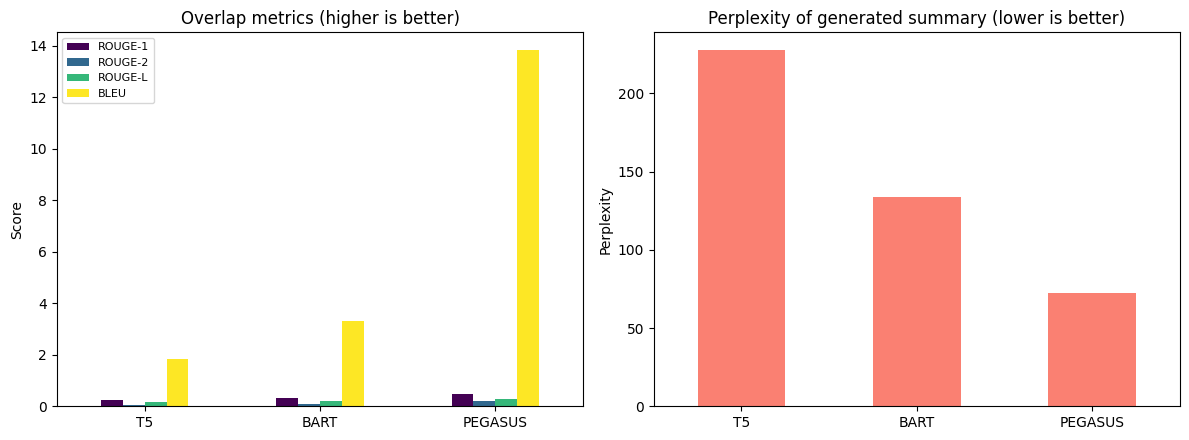


Final evaluation table:
         ROUGE-1  ROUGE-2  ROUGE-L     BLEU  Perplexity
T5        0.2487   0.0517   0.1503   1.8164    227.6842
BART      0.3073   0.0891   0.1925   3.3194    134.0158
PEGASUS   0.4636   0.1997   0.2644  13.8253     72.4696


In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

rouge_cols = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BLEU"]
results_df[rouge_cols].plot(kind="bar", ax=ax[0], colormap="viridis")
ax[0].set_title("Overlap metrics (higher is better)")
ax[0].set_ylabel("Score")
ax[0].tick_params(axis="x", rotation=0)
ax[0].legend(fontsize=8)

results_df["Perplexity"].plot(kind="bar", ax=ax[1], color="salmon")
ax[1].set_title("Perplexity of generated summary (lower is better)")
ax[1].set_ylabel("Perplexity")
ax[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print("\nFinal evaluation table:")
print(results_df.round(4).to_string())

## 10. End-to-End Pipeline Demo

Full flow on a single PDF: **PDF -> extract -> clean -> summarize -> structured info -> metrics.**

In [15]:
def summarize_paper_pdf(pdf_path, summarizer):
    raw = extract_text_from_pdf(pdf_path)
    cleaned = clean_text(raw)
    summary = summarizer.summarize_long(cleaned)
    info = extract_structured_info(cleaned, summarizer)
    return cleaned, summary, info


cleaned, summary, info = summarize_paper_pdf(DEMO_PDF, bart)

print("INPUT PDF              :", DEMO_PDF)
print("Characters extracted   :", len(cleaned))
print("\n================ GENERATED SUMMARY ================\n")
print(textwrap.fill(summary, 90))
print("\n================ STRUCTURED INFORMATION ================")
for field, val in info.items():
    print(f"\n[{field}]")
    print(textwrap.fill(val, 90))

r1, r2, rl = rouge_scores(summary, DATA[0]["abstract"])
print("\n================ QUALITY vs REFERENCE ABSTRACT ================")
print(f"ROUGE-1: {r1:.4f} | ROUGE-2: {r2:.4f} | ROUGE-L: {rl:.4f} | "
      f"Perplexity: {perplexity(summary):.2f}")

INPUT PDF              : sample_paper.pdf
Characters extracted   : 26024

================ GENERATED SUMMARY ================

Additive models @xcite provide an important family of models for semiparametric regression
or classification . Good estimators in additive models are less prone to the curse of high
dimensionality than in fully nonparametric models . In this paper we address the open
question whether an svm with an additive kernel can provide a substantially better
learning rate in high dimensions than a general kernel .

================ STRUCTURED INFORMATION ================

[Research Objective]
In this paper we address the open question whether an svm with an additive kernel can
provide a substantially better learning rate in high dimensions than a classical gaussian
rbf kernel . We establish learning rates for these algorithms .

[Methodology]
additive models @xcite provide an important family of models for semiparametric regression
or classification . Some reasons for th

## 11. Conclusion

- Built an **end-to-end research-paper summarization system** using Transformer
  **encoder-decoder** models (**T5**, **BART**, and optionally **PEGASUS**).
- Implemented the full NLP pipeline: **PDF extraction -> cleaning -> tokenization ->
  hierarchical (map-reduce) summarization -> structured information extraction -> evaluation**.
- Long documents are handled by chunking and a two-stage (map-reduce) summarization,
  overcoming the transformer context-length limit.
- Extracted the requested structured fields - *objective, methodology, dataset, key
  findings, conclusion* - enabling quick understanding of a paper.
- Evaluated summaries with **ROUGE-1/2/L**, **BLEU**, and **Perplexity**.

**Expected outcomes achieved:** automatic summary generation, faster literature survey,
improved accessibility of scientific information, and reduced manual effort for researchers.

In [ ]:
# BITS Virtual Lab execution screenshot
